

# **Goal:**  -> Estimate each customer's future revenue potential using the **BG/NBD + Gamma-Gamma** probabilistic model, assign CLV tiers, and identify high-value customers at risk of churning.

**Models used:**
- `BetaGeoFitter` (BG/NBD) — predicts *how many* purchases a customer will make
- `GammaGammaFitter` — predicts *how much* each future purchase is worth



---


# Dataset Load and Setup


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

TIER_COLORS = {
    'Platinum': '#7B2FBE',
    'Gold'    : '#F4A100',
    'Silver'  : '#607D8B',
    'Bronze'  : '#A0522D',
}

df  = pd.read_csv('./data/01_preprocessed.csv', parse_dates=['order_date'])
rfm = pd.read_csv('./data/02_rfm.csv')

print(f"Transactions : {len(df):,} rows")
print(f"Customers    : {df['customer_id'].nunique():,}")
print(f"Date range   : {df['order_date'].min().date()} → {df['order_date'].max().date()}")

Transactions : 34,500 rows
Customers    : 7,903
Date range   : 2023-09-12 → 2025-09-11


# Build Lifetimes Summary Table

`summary_data_from_transaction_data()` reshapes the transaction log into the
4-column format the BG/NBD model requires — one row per customer:

| Column | Meaning |
|---|---|
| `frequency` | Number of **repeat** purchases (= total orders − 1) |
| `recency` | Days between **first** and **last** purchase |
| `T` | Days since **first** purchase (customer age in database) |
| `monetary_value` | **Average** value of repeat transactions |

> ⚠️ Note: `frequency` here is **not** the same as RFM Frequency.
> In RFM, Frequency = total orders. Here, Frequency = total orders − 1.


In [32]:
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

summary = summary_data_from_transaction_data(
    df,
    customer_id_col       = 'customer_id',
    datetime_col          = 'order_date',
    monetary_value_col    = 'total_amount',
    observation_period_end= snapshot_date,
    freq                  = 'D'
)

one_timers = (summary['frequency'] == 0).sum()
print(f"Summary shape    : {summary.shape}")
print(f"One-time buyers  : {one_timers:,}  ({one_timers/len(summary)*100:.1f}%)")
print(f"Repeat buyers    : {(summary['frequency'] > 0).sum():,}")
print()
summary.describe().round(2)

Summary shape    : (7903, 4)
One-time buyers  : 477  (6.0%)
Repeat buyers    : 7,426



,frequency,recency,T,monetary_value
count,7903.00,7903.00,7903.00,7903.00
mean,3.35,411.05,570.06,156.62
std,2.04,199.24,149.63,200.90
min,0.00,0.00,2.00,0.00
25%,2.00,277.00,500.00,43.22
50%,3.00,448.00,619.00,99.04
75%,5.00,573.00,683.00,195.24
max,12.00,729.00,731.00,3475.78


# Gamma-Gamma Assumption Check

The Gamma-Gamma model requires that **frequency and monetary value are uncorrelated**.
Pearson |r| < 0.30 is the accepted threshold.


Pearson correlation (frequency vs monetary_value): 0.0209

✓  Assumption holds — Gamma-Gamma model is valid for this dataset.


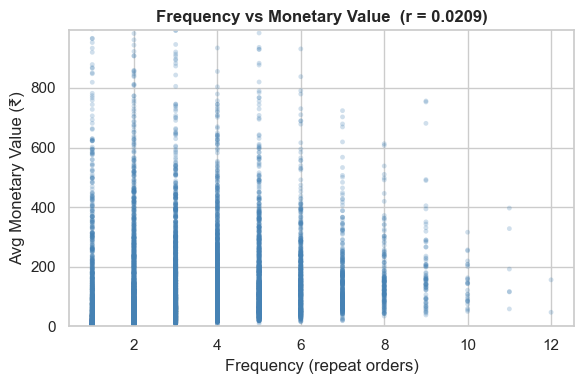

In [33]:
repeat_buyers = summary[summary['frequency'] > 0].copy()
corr = repeat_buyers[['frequency', 'monetary_value']].corr().iloc[0, 1]

print(f"Pearson correlation (frequency vs monetary_value): {corr:.4f}")
print()
if abs(corr) < 0.30:
    print("✓  Assumption holds — Gamma-Gamma model is valid for this dataset.")
else:
    print("⚠  Correlation exceeds 0.30 — Gamma-Gamma estimates may be biased.")

# Quick scatter to visualise
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(repeat_buyers['frequency'], repeat_buyers['monetary_value'],
           alpha=0.25, s=12, color='steelblue', edgecolors='none')
ax.set_title(f'Frequency vs Monetary Value  (r = {corr:.4f})', fontweight='bold')
ax.set_xlabel('Frequency (repeat orders)')
ax.set_ylabel('Avg Monetary Value (₹)')
ax.set_ylim(0, repeat_buyers['monetary_value'].quantile(0.99))
plt.tight_layout()
plt.show()

# BG/NBD Model — Predict Future Purchase Counts

The **Beta-Geometric / Negative Binomial Distribution** model treats each customer as
having two latent processes:
- **Transaction process** — how often they buy (follows a Poisson process)
- **Dropout process** — they can "die" (churn) after any transaction

`penalizer_coef=0.01` adds L2 regularisation to prevent parameter divergence on
synthetic/low-noise datasets.


In [34]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

print("BG/NBD model fitted ✓")
print()
print("Model parameters:")
param_descriptions = {
    'r'    : 'transaction rate shape',
    'alpha': 'transaction rate scale',
    'a'    : 'dropout rate shape (Beta)',
    'b'    : 'dropout rate scale (Beta)',
}
for param, val in bgf.params_.items():
    print(f"  {param:<8} = {val:.6f}   # {param_descriptions.get(param, '')}")

print()
print("⚠  Note: 'a' and 'b' near zero indicates the model detected minimal churn")
print("   in this dataset — expected behaviour with synthetic transaction data.")
print("   In a real dataset, a and b would be non-trivial, producing varied p(alive) scores.")

BG/NBD model fitted ✓

Model parameters:
  r        = 2.656526   # transaction rate shape
  alpha    = 449.082247   # transaction rate scale
  a        = 0.000000   # dropout rate shape (Beta)
  b        = 0.000012   # dropout rate scale (Beta)

⚠  Note: 'a' and 'b' near zero indicates the model detected minimal churn
   in this dataset — expected behaviour with synthetic transaction data.
   In a real dataset, a and b would be non-trivial, producing varied p(alive) scores.


In [35]:
# Predict expected purchases at 3 time horizons (in days)
for label, days in [('pred_90d', 90), ('pred_180d', 180), ('pred_365d', 365)]:
    raw = bgf.conditional_expected_number_of_purchases_up_to_time(
        days, summary['frequency'], summary['recency'], summary['T']
    )
    # Fallback for any NaN (numerical edge cases): linear extrapolation from frequency
    summary[label] = raw.fillna(summary['frequency'] * days / 730)

print("Predicted purchase counts (next 90 / 180 / 365 days):")
print(summary[['pred_90d', 'pred_180d', 'pred_365d']].describe().round(3))

Predicted purchase counts (next 90 / 180 / 365 days):
       pred_90d  pred_180d  pred_365d
count   7903.00    7903.00    7903.00
mean       0.53       1.06       2.09
std        0.16       0.33       0.77
min        0.20       0.00       0.00
25%        0.41       0.82       1.65
50%        0.52       1.04       2.10
75%        0.63       1.26       2.55
max        1.34       2.68       5.43


# Gamma-Gamma Model — Predict Expected Order Value

Trained on **repeat buyers only** (frequency > 0).
For one-time buyers we fall back to their actual single purchase value.


In [36]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(repeat_buyers['frequency'], repeat_buyers['monetary_value'])

print("Gamma-Gamma model fitted ✓")
print("Parameters:", dict(zip(['p', 'q', 'v'], ggf.params_.values.round(4))))
print()

# Expected average profit per future transaction
summary['exp_avg_val'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)

# Fix: one-time buyers have no repeat history — use their actual avg order value
actual_avg = df.groupby('customer_id')['total_amount'].mean().rename('actual_avg')
summary = summary.join(actual_avg)
mask_one_time = summary['frequency'] == 0
summary.loc[mask_one_time, 'exp_avg_val'] = summary.loc[mask_one_time, 'actual_avg']

print(f"One-time buyer monetary fix applied to {mask_one_time.sum()} customers.")
print()
print("Expected avg order value per customer:")
print(summary['exp_avg_val'].describe().round(2))

Gamma-Gamma model fitted ✓
Parameters: {'p': np.float64(3.6232), 'q': np.float64(0.4732), 'v': np.float64(3.5327)}

One-time buyer monetary fix applied to 477 customers.

Expected avg order value per customer:
count   7903.00
mean     178.51
std      227.28
min        1.24
25%       53.92
50%      111.22
75%      216.02
max     4071.25
Name: exp_avg_val, dtype: float64


# Compute CLV

`CLV = predicted_purchases × expected_avg_order_value`

We compute at 90-day, 180-day, and 365-day horizons.
Negative values (numerical artefacts) are clipped to zero.


In [37]:
summary['CLV_90d']  = (summary['pred_90d']  * summary['exp_avg_val']).clip(lower=0)
summary['CLV_180d'] = (summary['pred_180d'] * summary['exp_avg_val']).clip(lower=0)
summary['CLV_365d'] = (summary['pred_365d'] * summary['exp_avg_val']).clip(lower=0)

print("CLV computed for all customers ✓")
print(f"NaN check — CLV_180d: {summary['CLV_180d'].isna().sum()}  |  CLV_365d: {summary['CLV_365d'].isna().sum()}")
print()
print("CLV summary (₹):")
print(summary[['CLV_90d', 'CLV_180d', 'CLV_365d']].describe().round(2))

CLV computed for all customers ✓
NaN check — CLV_180d: 0  |  CLV_365d: 0

CLV summary (₹):
       CLV_90d  CLV_180d  CLV_365d
count  7903.00   7903.00   7903.00
mean     94.63    188.75    373.26
std     113.77    227.30    458.38
min       0.37      0.00      0.00
25%      26.12     51.76     97.17
50%      60.21    120.06    235.38
75%     122.84    245.57    487.02
max    1818.82   3637.63   7376.31


# CLV Tiers

Customers bucketed into four tiers based on their **180-day CLV** percentile.

| Tier | Percentile | Marketing priority |
|---|---|---|
| 🟣 Platinum | Top 10% | Maximum retention budget |
| 🟡 Gold | 75th – 90th | Loyalty & upsell programmes |
| ⚪ Silver | 50th – 75th | Standard nurture campaigns |
| 🟤 Bronze | Bottom 50% | Low-cost re-engagement |


In [38]:
summary['CLV_Tier'] = pd.qcut(
    summary['CLV_180d'],
    q      = [0, .50, .75, .90, 1.0],
    labels = ['Bronze', 'Silver', 'Gold', 'Platinum']
)

tier_stats = summary.groupby('CLV_Tier', observed=True).agg(
    Customers  = ('CLV_180d', 'count'),
    Avg_CLV    = ('CLV_180d', 'mean'),
    Total_CLV  = ('CLV_180d', 'sum'),
    Min_CLV    = ('CLV_180d', 'min'),
    Max_CLV    = ('CLV_180d', 'max'),
).round(2)
tier_stats['Pct_Revenue'] = (tier_stats['Total_CLV'] / tier_stats['Total_CLV'].sum() * 100).round(1)

print("=== CLV TIER SUMMARY ===")
print(tier_stats.to_string())

=== CLV TIER SUMMARY ===
          Customers  Avg_CLV  Total_CLV  Min_CLV  Max_CLV  Pct_Revenue
CLV_Tier                                                              
Bronze         3952    54.87  216844.86     0.00   120.06        14.50
Silver         1975   174.58  344804.75   120.07   245.51        23.10
Gold           1185   315.00  373269.26   245.62   421.95        25.00
Platinum        791   703.90  556787.68   421.95  3637.63        37.30


# At-Risk High-Value Customer Identification

Since `p(alive)` is near 1.0 for all customers in this synthetic dataset
(the BG/NBD model detected no meaningful churn signal), we identify at-risk customers
using a **combined recency + CLV approach**:

- **High value**: CLV Tier = Gold or Platinum
- **Disengaged**: RFM Segment = *At Risk* or *Can't Lose Them*

These are the customers with the highest revenue potential who are already showing
disengagement signals in their purchase behaviour — the most critical cohort to win back.


In [39]:
# Merge CLV with RFM segments
clv_rfm = summary.reset_index().merge(
    rfm[['customer_id', 'Segment', 'Recency', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']],
    on='customer_id', how='left'
)

# At-risk definition: high CLV tier + disengaged RFM segment
high_value   = clv_rfm['CLV_Tier'].isin(['Gold', 'Platinum'])
disengaged   = clv_rfm['Segment'].isin(['At Risk', "Can't Lose Them"])
clv_rfm['at_risk_flag'] = (high_value & disengaged).astype(int)

at_risk = clv_rfm[clv_rfm['at_risk_flag'] == 1].copy()
at_risk_revenue = at_risk['CLV_180d'].sum()
total_revenue   = clv_rfm['CLV_180d'].sum()

print(f"At-risk high-value customers : {len(at_risk):,}")
print(f"% of total customer base     : {len(at_risk)/len(clv_rfm)*100:.1f}%")
print(f"Their 180d CLV at stake      : ₹{at_risk_revenue:,.0f}")
print(f"% of total forecast revenue  : {at_risk_revenue/total_revenue*100:.1f}%")
print()
print("Segment breakdown of at-risk customers:")
print(at_risk.groupby(['Segment', 'CLV_Tier'], observed=True)['CLV_180d']
      .agg(['count', 'mean']).round(2))

At-risk high-value customers : 478
% of total customer base     : 6.0%
Their 180d CLV at stake      : ₹218,604
% of total forecast revenue  : 14.7%

Segment breakdown of at-risk customers:
                          count   mean
Segment         CLV_Tier              
At Risk         Gold        138 312.70
                Platinum    111 679.26
Can't Lose Them Gold        148 317.92
                Platinum     81 654.34


# Visualisations

### 1.Predicted Purchase Counts — 3 Horizons

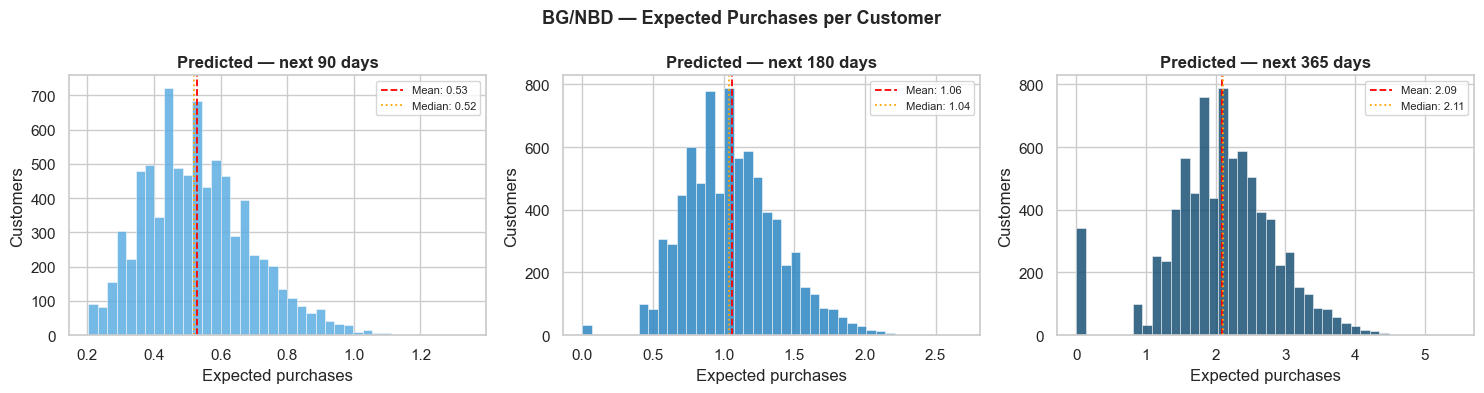

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('BG/NBD — Expected Purchases per Customer', fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, [
    ('pred_90d',  '90 days',  '#5DADE2'),
    ('pred_180d', '180 days', '#2E86C1'),
    ('pred_365d', '365 days', '#1A5276'),
]):
    ax.hist(summary[col], bins=40, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(summary[col].mean(),   color='red',    linestyle='--', linewidth=1.3,
               label=f'Mean: {summary[col].mean():.2f}')
    ax.axvline(summary[col].median(), color='orange', linestyle=':',  linewidth=1.3,
               label=f'Median: {summary[col].median():.2f}')
    ax.set_title(f'Predicted — next {label}', fontweight='bold')
    ax.set_xlabel('Expected purchases')
    ax.set_ylabel('Customers')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

 ### 2. CLV Distribution (180 Days)

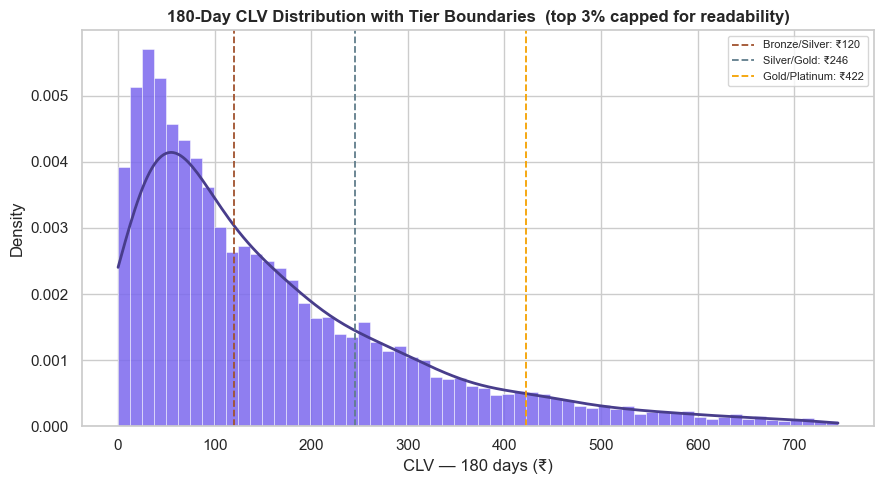

In [41]:
clv_cap = summary['CLV_180d'].quantile(0.97)   # cap for readability
plot_clv = summary[summary['CLV_180d'] <= clv_cap]['CLV_180d']

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(plot_clv, bins=60, color='mediumslateblue', edgecolor='white', linewidth=0.4, alpha=0.85, density=True)

# KDE overlay
from scipy.stats import gaussian_kde
kde_x = np.linspace(plot_clv.min(), plot_clv.max(), 300)
kde   = gaussian_kde(plot_clv, bw_method=0.25)
ax.plot(kde_x, kde(kde_x), color='darkslateblue', linewidth=2)

# Tier boundary lines
thresholds = summary['CLV_180d'].quantile([0.50, 0.75, 0.90])
tier_labels = ['Bronze/Silver', 'Silver/Gold', 'Gold/Platinum']
tier_cols   = ['#A0522D', '#607D8B', '#F4A100']
for (q, label, c) in zip(thresholds, tier_labels, tier_cols):
    ax.axvline(q, linestyle='--', linewidth=1.3, color=c, label=f'{label}: ₹{q:.0f}')

ax.set_title('180-Day CLV Distribution with Tier Boundaries  (top 3% capped for readability)',
             fontweight='bold')
ax.set_xlabel('CLV — 180 days (₹)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3. CLV By RFM Segmentation

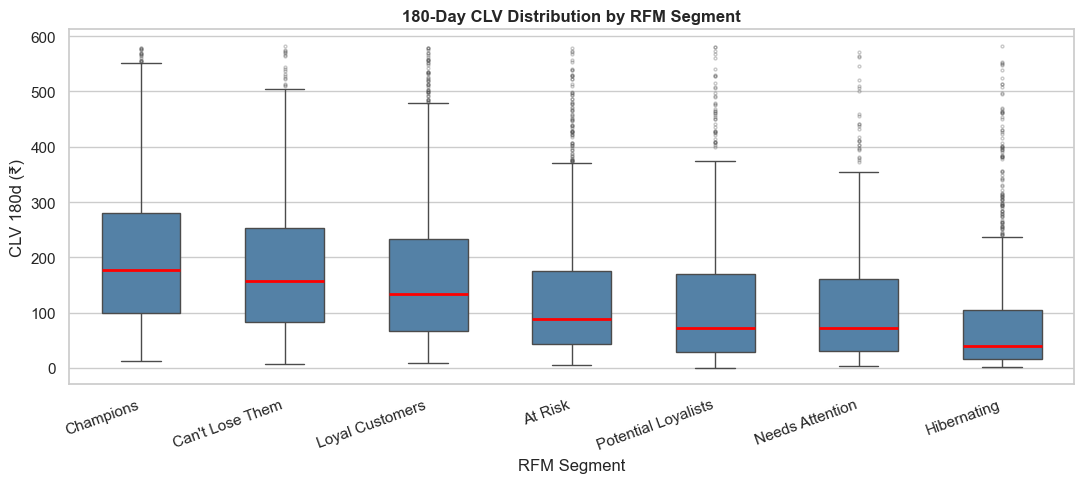

In [42]:
seg_order = clv_rfm.groupby('Segment')['CLV_180d'].median().sort_values(ascending=False).index.tolist()
clv_cap_box = clv_rfm['CLV_180d'].quantile(0.95)
plot_box = clv_rfm[clv_rfm['CLV_180d'] <= clv_cap_box]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=plot_box, x='Segment', y='CLV_180d',
    order=seg_order, ax=ax, color='steelblue',
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    width=0.55
)
ax.set_title('180-Day CLV Distribution by RFM Segment', fontweight='bold', fontsize=12)
ax.set_xlabel('RFM Segment')
ax.set_ylabel('CLV 180d (₹)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 4. CLV tier BY Revenue share and Customer count

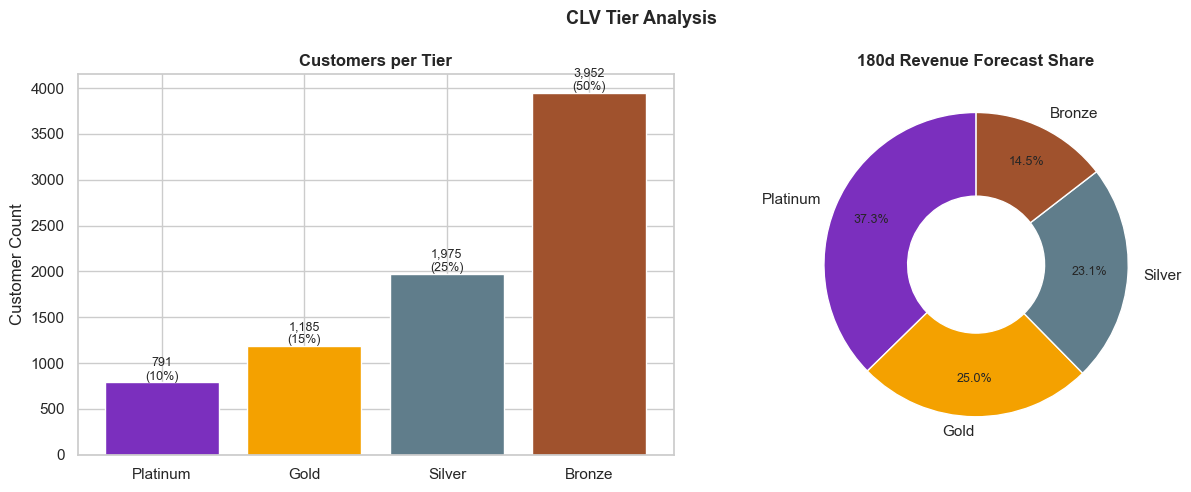

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CLV Tier Analysis', fontsize=13, fontweight='bold')

tier_order  = ['Platinum', 'Gold', 'Silver', 'Bronze']
tier_colors = [TIER_COLORS[t] for t in tier_order]
ts          = tier_stats.reindex(tier_order)

# Customer count
bars = axes[0].bar(tier_order, ts['Customers'], color=tier_colors, edgecolor='white')
axes[0].set_title('Customers per Tier', fontweight='bold')
axes[0].set_ylabel('Customer Count')
for bar in bars:
    h = bar.get_height()
    pct = h / ts['Customers'].sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 30,
                 f'{int(h):,}\n({pct:.0f}%)', ha='center', fontsize=9)

# Revenue share (donut)
wedges, texts, autotexts = axes[1].pie(
    ts['Total_CLV'], labels=tier_order, colors=tier_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55)
)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[1].set_title('180d Revenue Forecast Share', fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Top 20 By 180 Days CLV

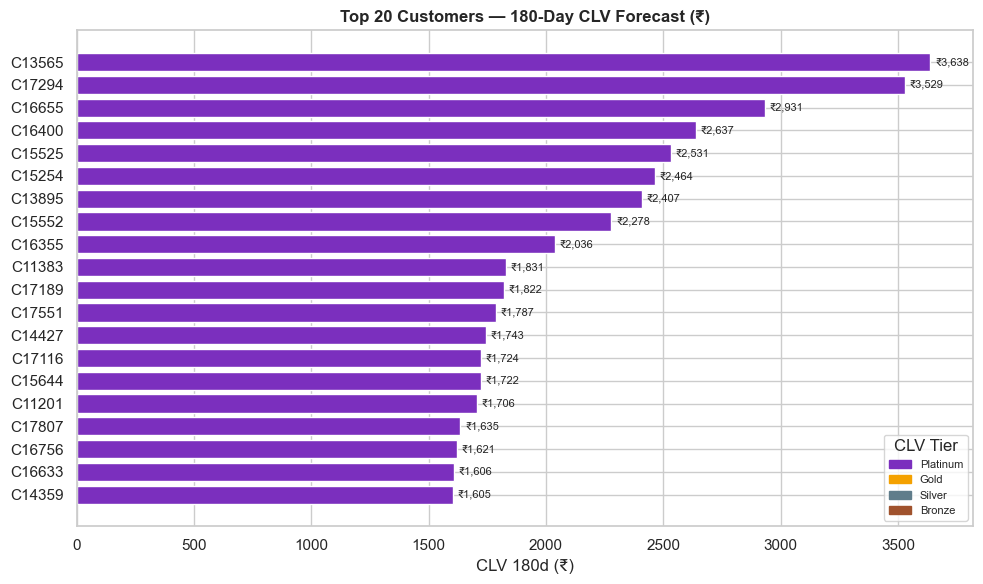

In [44]:
top20 = clv_rfm.nlargest(20, 'CLV_180d')[['customer_id','CLV_180d','CLV_365d',
                                           'CLV_Tier','Segment','Recency','frequency']].copy()
top20 = top20.reset_index(drop=True)
top20.index += 1

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [TIER_COLORS[t] for t in top20['CLV_Tier']]
bars = ax.barh(top20['customer_id'].astype(str), top20['CLV_180d'],
               color=bar_colors, edgecolor='white')
ax.set_title('Top 20 Customers — 180-Day CLV Forecast (₹)', fontweight='bold')
ax.set_xlabel('CLV 180d (₹)')
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 20, bar.get_y() + bar.get_height()/2,
            f'₹{w:,.0f}', va='center', fontsize=8)

# Legend for tiers
handles = [plt.Rectangle((0,0),1,1, color=TIER_COLORS[t]) for t in tier_order]
ax.legend(handles, tier_order, title='CLV Tier', loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

In [45]:
import os
os.makedirs('./data', exist_ok=True)

# Full CLV table — primary output for Phase 5 Dashboard
clv_out = clv_rfm[[
    'customer_id', 'frequency', 'recency', 'T', 'monetary_value',
    'pred_90d', 'pred_180d', 'pred_365d',
    'exp_avg_val', 'CLV_90d', 'CLV_180d', 'CLV_365d',
    'CLV_Tier', 'at_risk_flag',
    'Segment', 'Recency', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score'
]]
clv_out.to_csv('./data/04_clv.csv', index=False)

# At-risk high-value customers — action list for marketing
at_risk_sorted = at_risk.sort_values('CLV_180d', ascending=False)
at_risk_sorted[['customer_id','CLV_180d','CLV_365d','CLV_Tier','Segment',
                 'Recency','frequency','monetary_value']]    .to_csv('../data/04_at_risk.csv', index=False)

